In [1]:
!pwd

/users/khordadi


In [2]:
import os
import sys
from pathlib import Path

project_root = '/users/khordadi/truejit/evaluation/compilation-plan'
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from solver import *
from profiling import *

In [ ]:
plans = []
for mode in compilation_plans:
    plan = solver_output_as_df(f'/tmp/truejit/CAPER/results/gcc-loops.{mode}.json')
    plan = plan['mode.solver'].plans_titles()
    plans.append((mode, plan))

fns_size = len(plans[0][1])

# prepend plan for jit and interp
plans.insert(0, ('interp', ['interpret'] * fns_size))
plans.insert(0, ('jit', ['jit'] * fns_size))

print(f'Number of functions: {fns_size}')
assert all(len(plan) == fns_size for _, plan in plans), "Not all plans have the same length"

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Your data lists
data = [plan for _, plan in plans]
modes = [mode for mode, _ in plans]

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns

mapping = {'interpret': 0, 'specialized': 1, 'static': 2, 'async': 3, 'jit': 4}
numeric_data = np.array([[mapping[item] for item in row] for row in data])

colors = [
    'skyblue',  # interpret
    'pink',  # specialized
    'crimson',  # static
    'navy',  # async
    'lightgray'  # jit
]
cmap = mcolors.ListedColormap(colors)

# 4. Plot
plt.figure(figsize=(30, 4), dpi=320)
functions_colors = sns.heatmap(numeric_data, cmap=cmap, cbar=False, linewidths=0.001, linecolor='white')

# 5. Add a custom legend
labels = ["Interpret", "Specialized", "Static", "Async", "JIT"]
patches = [plt.plot([], [], marker="s", ms=10, ls="", mec=None, color=colors[i], label=labels[i])[0] for i in
           range(len(labels))]

plt.legend(handles=patches, bbox_to_anchor=(.4, 1.09), ncol=5, loc=2, borderaxespad=0.)

plt.xlabel('Functions')
plt.xticks([])

plt.ylabel('Optimization Goals')
plt.yticks([i + 0.5 for i in range(len(modes))],
           [compilation_plans_names[mode] for mode in modes],
           rotation=0, fontsize=12,
           va='center')

plt.tight_layout()
plt.show()

In [ ]:
for plan in plans:
    print(plan)

In [ ]:
# get the end-to-end time for jit interp and minimize_end_to_end_time
# minimizer = {
#     'dynamic_code_size': 'minimize_dyn_code_size',
#     'static_code_size': 'minimize_bin_file_size',
#     'e2e': 'minimize_end_to_end_time',
#     'waiting': 'minimize_jit_latency',
#     'startup': 'minimize_startup_time',
#     'cpu': 'minimize_CPU_utilization'
# }
#
# goal_name = {
#     'dynamic_code_size': 'Minimize Dynamic Code Size',
#     'static_code_size': 'Minimize Binary File Size',
#     'e2e': 'Minimize End-to-End Time',
#     'waiting': 'Minimize JIT Latency',
#     'startup': 'Minimize Startup Time',
#     'cpu': 'Minimize CPU Utilization'
# }
#
# metric_name = {
#     'dynamic_code_size': 'Dynamic Code Size',
#     'static_code_size': 'Binary File Size',
#     'e2e': 'End-to-End Time',
#     'waiting': 'JIT Latency',
#     'startup': 'Startup Time',
#     'cpu': 'CPU Utilization'
# }

# (metric, metric_name, minimizer_plan)
goals = [
    ('dynamic_code_size', 'Dynamic Code Size', 'minimize_dyn_code_size'),
    ('static_code_size', 'Binary File Size', 'minimize_bin_file_size'),
    ('e2e', 'End-to-End Time', 'minimize_end_to_end_time'),
    ('waiting', 'JIT Latency', 'minimize_jit_latency'),
    ('startup', 'Startup Time', 'minimize_startup_time'),
    ('cpu', 'CPU Utilization', 'minimize_CPU_utilization'),
]

metrics_map = {}
for metric, metric_name, minimizer_plan in goals:
    plan = solver_output_as_df(f'/tmp/truejit/CAPER/results/gcc-loops.{minimizer_plan}.json')
    data = []
    for mode in [minimizer_plan, 'jit', 'interp']:
        val = metrics[metrics["mode"] == mode][metric].iloc[0]
        print(f'\t{mode}: {val}')
        data.append(val)

        # data = [d / data[0] for d in data]

    # plot as 3 bars
    colors = {
        'jit': 'lightgray',
        'interpret': 'skyblue',
        'specialized': 'pink',
        'static': 'crimson',
        'async': 'navy'
    }

    data = [('CAPER', data[0]), ('JIT', data[1]), ('Interpret', data[2])]

    plan = plan['mode.solver'].plans_titles()
    print(f'len(plan): {len(plan)}')

    num_cols = 100
    num_rows = (len(plan) // num_cols) + 1

    cell_size = 1

    print(f'num_cols: {num_cols}, num_rows: {num_rows}')
    print(f'width: {num_cols * cell_size}, height: {num_rows * cell_size}')

    fig = plt.figure(
        # figsize=(num_rows * cell_size, num_cols * cell_size / 20),
        figsize=(12, 1.75),
        dpi=320)
    gs = GridSpec(1, 2, width_ratios=[8, 1])  # 3:1 → 75% / 25%
    functions_colors = fig.add_subplot(gs[0])
    bar_chart = fig.add_subplot(gs[1])

    for y in range(num_rows):
        for x in range(num_cols):
            if y * num_cols + x < len(plan):
                color = colors[plan[y * num_cols + x]]
                functions_colors.add_patch(
                    plt.Rectangle((x, y), cell_size, cell_size, facecolor=color, edgecolor='white'))
            else:
                functions_colors.add_patch(
                    plt.Rectangle((x, y), cell_size, cell_size, facecolor='white', edgecolor='white'))

    for y in range(num_rows):
        # val = (num_cols * num_rows) - ((y + 1) * num_cols)
        val = (y) * num_cols
        if val % 200 == 0:
            functions_colors.text(0 - cell_size / 2, y + cell_size / 2, str(val), ha='right', va='center')

    for x in range(num_cols):
        if (x + 1) % 10 == 0:
            functions_colors.text(x + cell_size / 2, cell_size / 2 - 1, str(x + 1), ha='center', va='top')

    functions_colors.set_xlim(0, num_cols)
    functions_colors.set_ylim(0, num_rows)
    functions_colors.set_aspect('equal')
    functions_colors.axis('off')

    # bar chart e2e_times
    xs, ys = zip(*data)
    # ys = [y / ys[0] for y in ys]
    bar_chart.bar(xs, ys)
    bar_chart.set_yscale('log')
    # y is relative time to CAPER
    bar_chart.set_ylabel(metric_name)
    # draw a horz loine at 1
    # bar_chart.axhline(1, color='black', linestyle='--', linewidth=.5)

    # title is Minimize End-to-End Time

    # fig.suptitle(goal_name[criteria], fontsize=16)

    # tight layout
    plt.tight_layout()

    # write to png
    fig.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/{minimizer_plan}.png', dpi=320)

    plt.show()

In [1]:
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *


# benchmark
# workload
# exec_mode (jit, interp, planned)
# if planned
# plan_objective (min_e2e, min_startup, min_cpu, min_latency)
# plan_constraints (e.g., static_code_size < 5% of binary size)
# plan_input (leave_one_out, union, oracle)
# default decision (jit, aot, interp)


class Plan:
    def __init__(self, objective, constraint, default, input_profile):
        self.objective = objective
        self.constraint = constraint
        self.default = default
        self.input = input_profile


# implement it using pattern matcing
# define ExecutionMode which is an enum of 'jit', 'interp', 'planned'
class ExecutionMode:
    pass


class JIT(ExecutionMode):
    pass


class Interp(ExecutionMode):
    pass


class Planned(ExecutionMode):
    plan: Plan


def get_profile(binary, workload_name, plan_name):
    if plan_name in ['jit', 'interp']:
        return Profile(profiles_root(binary, workload_name, plan_name))
    elif plan_name == 'leave_one_out':
        return Profile(profiles_root(binary, workload_name, plan_name) / 'leave_one_out')
    elif plan_name == 'union':
        return Profile(profiles_root(binary, workload_name, plan_name) / 'union')
    elif plan_name == 'oracle':
        return Profile(profiles_root(binary, workload_name, plan_name) / f'trained_on_{workload_name}')
    else:
        raise ValueError(f'Unknown plan name: {plan_name}')


def get_plan_name(plan):
    return {
        'jit': 'JIT',
        'interp': 'Interpreter',
        'leave_one_out': 'Leave-One-Out',
        'union': 'Union',
        'oracle': 'Oracle',
    }[plan]


plan_names = ['jit', 'interp', 'leave_one_out', 'union', 'oracle']

benchmark = ffmpeg

profiles = []
for wl in benchmark.workloads:
    wl_profiles = []
    wl_profiles.append(('JIT', profiles_root(benchmark.binary, wl.name, 'jit')))
    wl_profiles.append(('Interpreter', profiles_root(benchmark.binary, wl.name, 'interp')))

    for plan_title, plan_name in [
        # (r'Minimize E2E Time (Constrained: Static Code Size $<$ 5\% of Binary Size; Default: JIT)', 'min_e2e.file_size_lt_5percent'),
        ('Minimize E2E Time (Unconstrained; Default: JIT)', 'min_e2e.unconstrained.default_jit'),
        ('Minimize E2E Time (Unconstrained; Default: Static)', 'min_e2e.unconstrained.default_static'),
    ]:
        wl_profiles.append(
            (f'{plan_title} | Leave-One-Out', profiles_root(benchmark.binary, wl.name, plan_name) / 'leave_one_out'))
        wl_profiles.append((f'{plan_title} | Union', profiles_root(benchmark.binary, wl.name, plan_name) / 'union'))
        wl_profiles.append(
            (f'{plan_title} | Oracle', profiles_root(benchmark.binary, wl.name, plan_name) / f'oracle'))
    profiles.extend([(wl.name, plan, profile_path) for plan, profile_path in wl_profiles])

df = []
for wl_name, plan_title, profile_path in profiles:
    profile = Profile(profile_path)
    df.append([
        wl_name,
        plan_title,
        profile.waiting,
        profile.exec,
        profile.compilation,
        profile.e2e,
        profile.dynamic_code_size,
        profile.static_code_size
    ])
df = pd.DataFrame(df, columns=['workload',
                               'config',
                               'waiting',
                               'exec',
                               'compilation',
                               'e2e',
                               'code.dynamic',
                               'code.static'])

df

,workload,config,waiting,exec,compilation,e2e,code.dynamic,code.static
0,mov-to-mp4,JIT,"[38896113815, 39062071587, 38992678461, 391323...","[74569595271, 74489827414, 75096520513, 747818...","[38665500872, 38839821293, 38760497150, 389049...","[113465709086, 113551899001, 114089198974, 113...","[5067408, 5067408, 5067408, 5067408, 5067408, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
1,mov-to-mp4,Interpreter,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[11486985277416, 11607819874885, 1146763729224...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[11486985277416, 11607819874885, 1146763729224...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,mov-to-mp4,Minimize E2E Time (Unconstrained; Default: JIT...,"[522487330, 521665971, 522540508, 512448459, 5...","[105681554401, 83735888382, 100438166376, 8825...","[516307407, 515431401, 516406342, 506282129, 5...","[106204041731, 84257554353, 100960706884, 8876...","[76384, 76384, 76384, 76384, 76384, 76384, 763...","[6168776, 6168776, 6168776, 6168776, 6168776, ..."
3,mov-to-mp4,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[80149255715, 93097993252, 95648673185, 111421...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[80149255715, 93097993252, 95648673185, 111421...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[6248440, 6248440, 6248440, 6248440, 6248440, ..."
4,mov-to-mp4,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91331940543, 96086497106, 84390047415, 804944...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[91331940543, 96086497106, 84390047415, 804944...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5034096, 5034096, 5034096, 5034096, 5034096, ..."
...,...,...,...,...,...,...,...,...
123,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[109725979176, 130811305410, 139285552809, 110...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[109725979176, 130811305410, 139285552809, 110...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[6248440, 6248440, 6248440, 6248440, 6248440, ..."
124,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: JIT...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[139948067230, 105894167534, 129992817166, 103...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[139948067230, 105894167534, 129992817166, 103...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[5072880, 5072880, 5072880, 5072880, 5072880, ..."
125,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: Sta...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[127360041123, 119803306820, 111250381668, 118...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[127360041123, 119803306820, 111250381668, 118...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[54937072, 54937072, 54937072, 54937072, 54937..."
126,mp4-gaussian-blur,Minimize E2E Time (Unconstrained; Default: Sta...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[114024286362, 112593571648, 112448326172, 121...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[114024286362, 112593571648, 112448326172, 121...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[54929696, 54929696, 54929696, 54929696, 54929..."


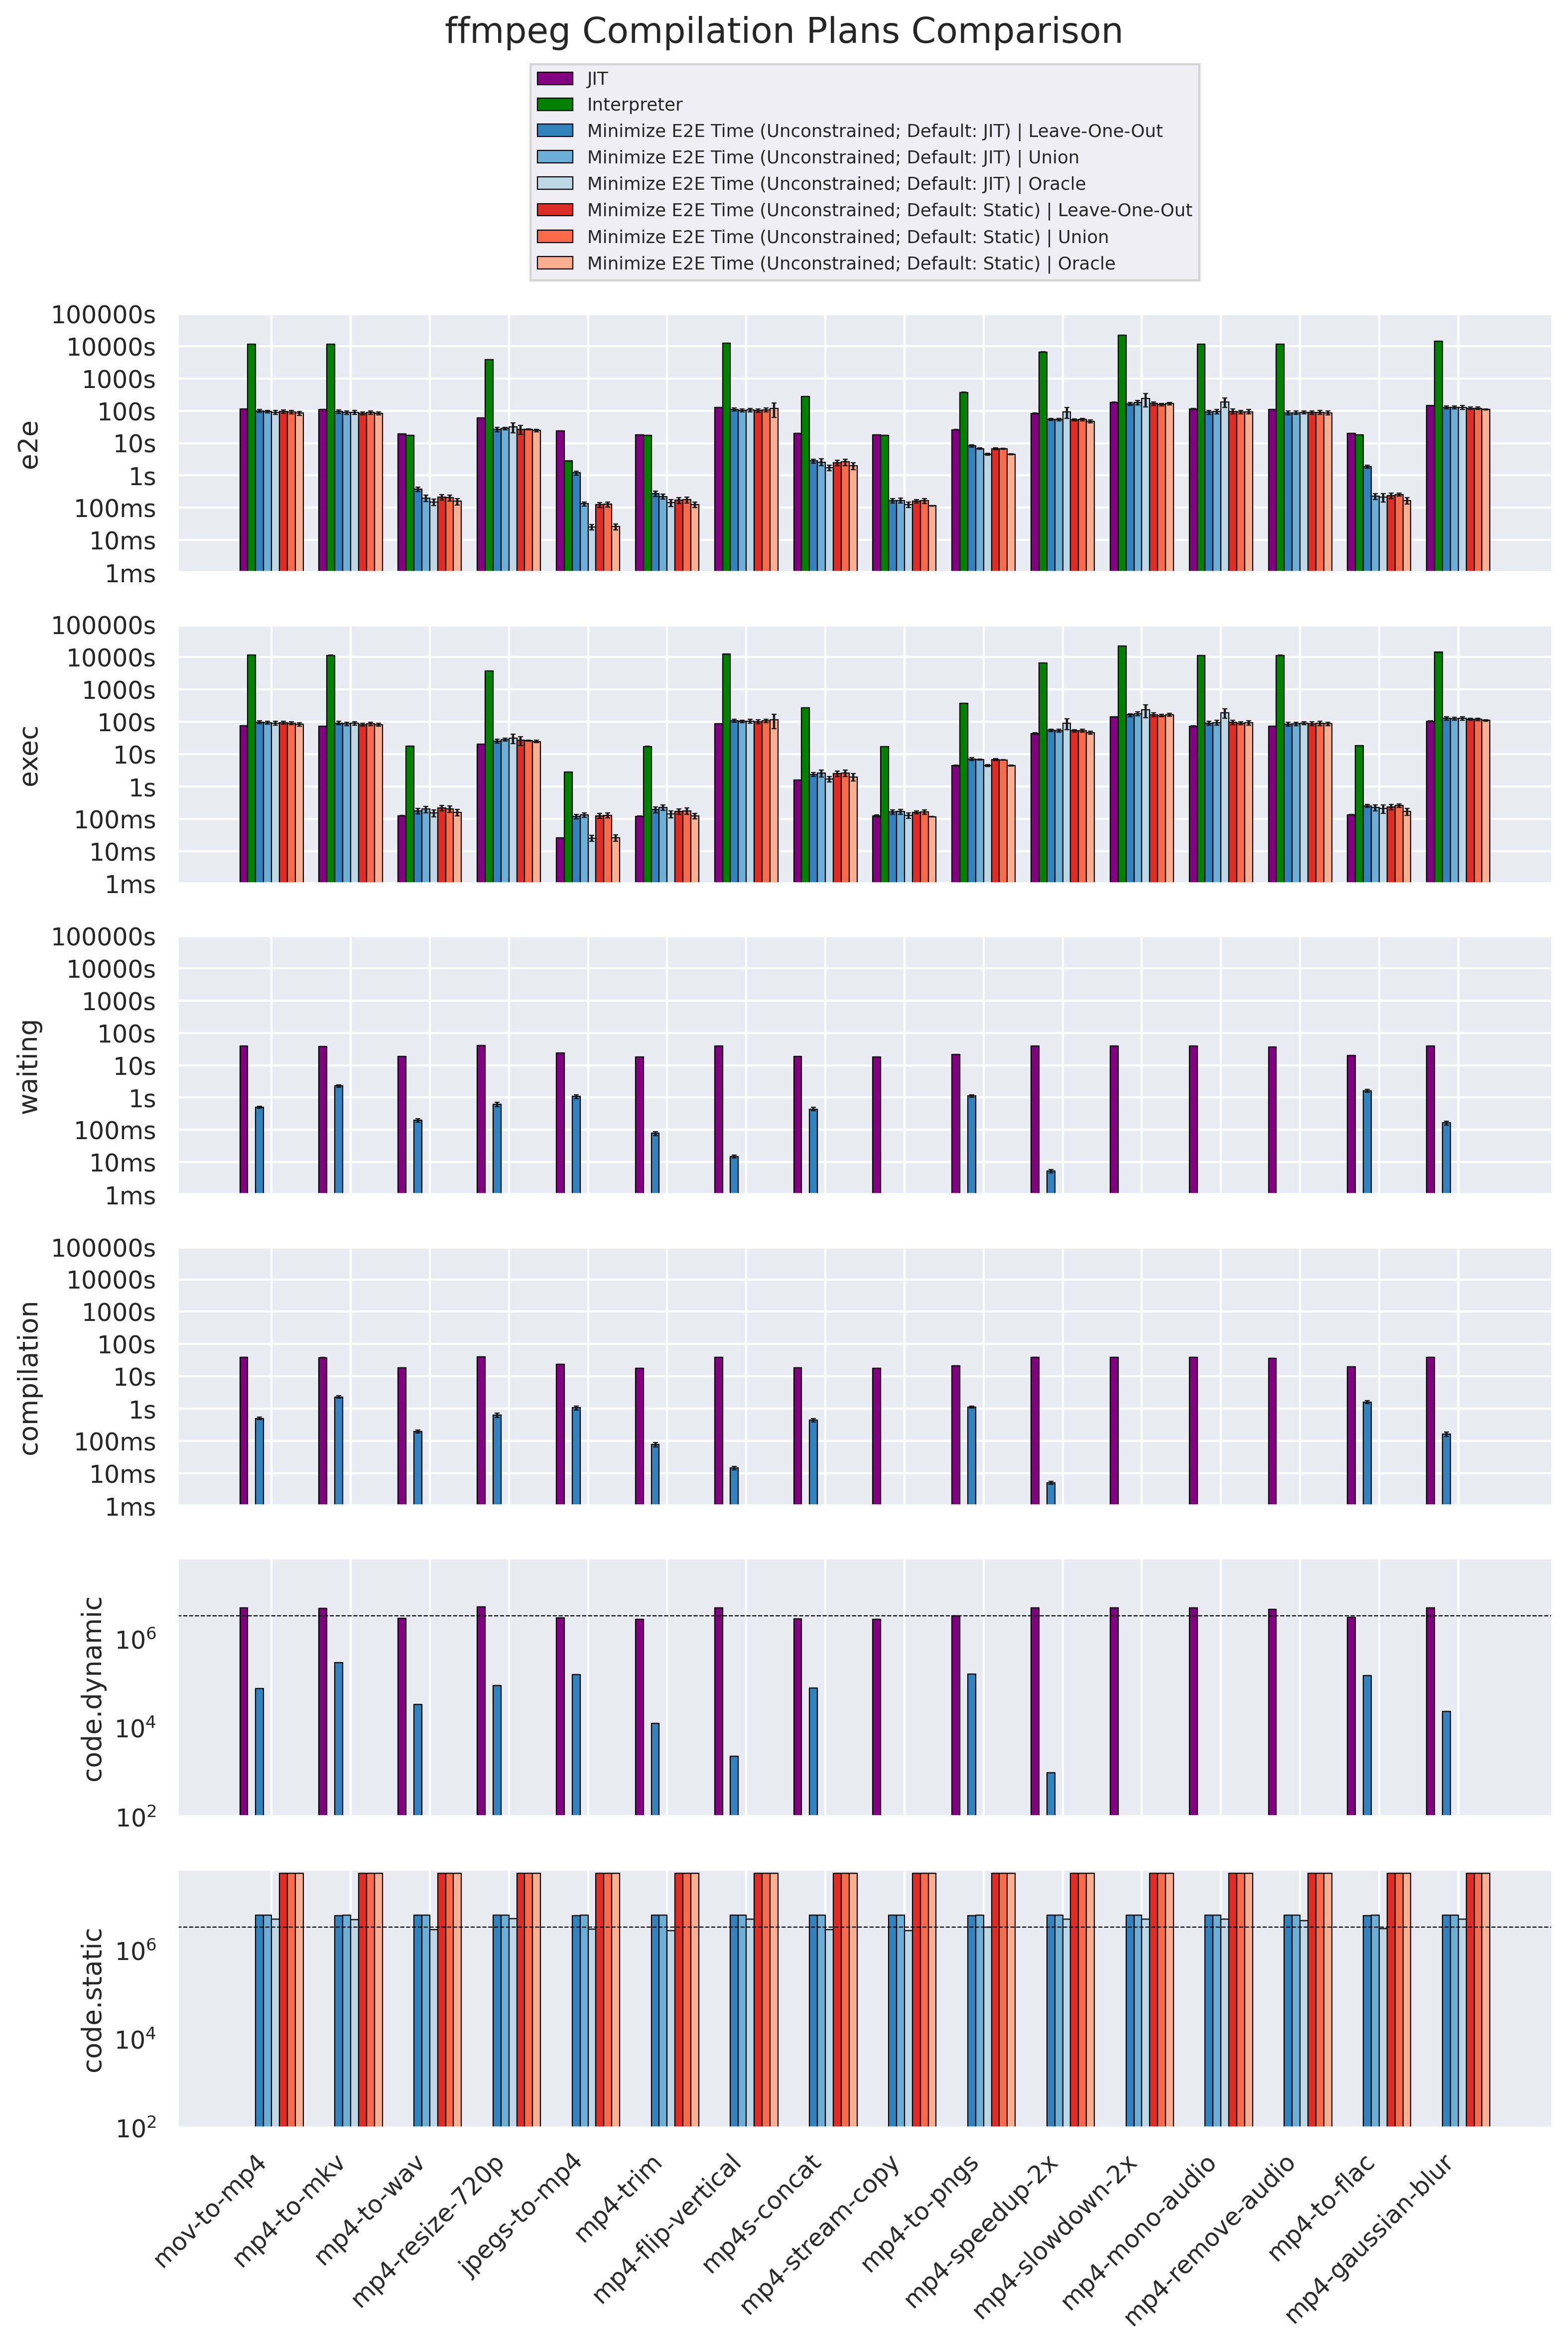

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from bokeh import palettes

# get unique plan titles
plans_titles = df['config'].unique().tolist()
# print(plan_titles)

metrics = [
    "e2e",
    "exec",
    "waiting",
    "compilation",
    "code.dynamic",
    "code.static",
]

plan_colors = []
plan_colors.append('purple')  # jit
plan_colors.append('green')  # interp
plan_colors.extend(palettes.Blues5[1:-1])
plan_colors.extend(palettes.Reds5[1:-1])

get_metric = lambda workload, config, metric: \
    df.loc[(df["workload"] == workload) & (df["config"] == config), metric].iloc[0]

workloads_names = df.workload.unique().tolist()
# print(workloads_names)

n_plans = len(plans_titles)
bar_width = 0.1
# offsets so the group of bars is centered at each xs
offsets = (np.arange(n_plans) - (n_plans - 1) / 2) * bar_width

sns.set_theme()
fig, axs = plt.subplots(len(metrics), 1, figsize=(10, len(metrics) * 2.5), dpi=320, sharex=True)

xs = np.arange(len(workloads_names))

for metric_idx, metric in enumerate(metrics):
    for plan_bar_idx, plan_title in enumerate(plans_titles):
        ys = [get_metric(wl, plan_title, metric) for wl in workloads_names]  # list of lists

        means = [np.mean(v) for v in ys]
        stds = [np.std(v) for v in ys]

        positions = xs + offsets[plan_bar_idx]

        axs[metric_idx].bar(
            positions,
            means,
            yerr=stds,
            error_kw=dict(elinewidth=1, capsize=1.2, capthick=.5),
            width=bar_width,
            label=plan_title,
            color=plan_colors[plan_bar_idx],
            edgecolor='black',
            linewidth=0.5
        )

    axs[metric_idx].set_xticks([])
    axs[metric_idx].set_yscale('linear')
    axs[metric_idx].set_ylabel(metric)
    axs[metric_idx].grid(axis='y')

    if metric.startswith("code."):
        binary_size = Path(benchmark.binary).stat().st_size
        # set max of y to binary size
        axs[metric_idx].set_ylim(100, binary_size)
        axs[metric_idx].axhline(binary_size * .05, color='black', linestyle='--', linewidth=.5)
        axs[metric_idx].set_yscale('log')

    if metric in ['e2e', 'waiting', 'compilation', 'exec']:
        axs[metric_idx].set_yscale('log')
        axs[metric_idx].set_ylim(1e6, 1e14)
        # print 1ms, 1s, 1000s
        axs[metric_idx].set_yticks([1e6, 1e7, 1e8, 1e9, 1e10, 1e11, 1e12, 1e13, 1e14])
        axs[metric_idx].set_yticklabels(['1ms', '10ms', '100ms', '1s', '10s', '100s', '1000s', '10000s', '100000s'])

        # draw grid
        axs[metric_idx].grid(axis='y')

        # if metric in ['embedded', 'interpreted', 'bgjit']:

# put legend out of the figure top center
axs[0].legend(loc='upper center', bbox_to_anchor=(0.5, 2), ncol=1, fancybox=False, shadow=False, frameon=True,
              fontsize=8)
axs[-1].set_xticks(xs, workloads_names, rotation=45, ha='right')

# set title
fig.suptitle(f'{benchmark.name} Compilation Plans Comparison', fontsize=16)

plt.tight_layout()

# to pdf
plt.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/comparison.pdf', dpi=320)

plt.show()

In [2]:
import pandas as pd
import numpy as np
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *


In [17]:
def get_name(plan):
    return {
        'min_e2e.unconstrained.default_static': 'Minimize End-to-End Time (Unconstrained; Default: AOT)',
        'min_e2e.unconstrained.default_jit': 'Minimize End-to-End Time (Unconstrained; Default: JIT)',
        # 'min_e2e.file_size_lt_5percent': r'Minimize End-to-End Time (Constrained: Static Code Size $<$ 5\% of Binary Size; Default: JIT)',
    }[plan]

In [18]:
def get_profiles_matrix(benchmark, plan):
    profiles = []
    for wl_validation in benchmark.workloads:
        wl_profiles = []
        # print(f'[validation] {wl_validation.name}')
        for wl_trained in benchmark.workloads:
            # print(f'[trained] {wl_trained.name}')
            path = profiles_root(benchmark.binary, wl_validation.name, plan) / f'trained_on_{wl_trained.name}'
            # print(path)
            if not path.exists():
                raise ValueError(f'No profile found for {plan} on {wl_validation.name} trained on {wl_trained.name}')
            else:
                wl_profiles.append(Profile(path))
        profiles.append(wl_profiles)
    return profiles


plan = 'min_e2e.unconstrained.default_jit'
# plan = 'min_e2e.file_size_lt_5percent'
profiles_matrix = get_profiles_matrix(ffmpeg, plan)

In [20]:
benchmark = ffmpeg
matrices = []
plans = [
    'min_e2e.unconstrained.default_static',
    'min_e2e.unconstrained.default_jit',
]
for plan in plans:
    profiles_matrix = get_profiles_matrix(benchmark, plan)

    matrix = np.zeros((len(benchmark.workloads), len(benchmark.workloads)))
    for i, wl_validation in enumerate(benchmark.workloads):
        print(f'[{wl_validation.name}]')
        for j, wl_trained in enumerate(benchmark.workloads):
            # metric = profiles_matrix[i][j]['exec'].sum()
            metric = np.average(profiles_matrix[i][j].e2e)
            matrix[i, j] = metric

        # print row
        print('before normalization:')
        print(*matrix[i], sep='\t')
        baseline = matrix[i, i]
        matrix[i, :] = baseline / matrix[i, :]
        print('after normalization:')
        print(*matrix[i], sep='\t')
        print()

    matrices.append(matrix)

[mov-to-mp4]
before normalization:
89746655865.71428	87665928427.0	86981121400.0	91609761199.0	111434841762.57143	86975829345.90475	85167977754.66667	86359521150.42857	87985198608.85715	85385309969.80952	91335047166.95238	90849056302.61905	88074228888.57143	85974057152.85715	88232115332.04762	89312617867.66667
after normalization:
1.0	1.0237347333912845	1.0317946517727268	0.9796625893474542	0.8053733863321935	1.0318574314340814	1.0537605592120183	1.0392213234877217	1.0200199270412265	1.0510784102961837	0.9826091806978031	0.987865581858851	1.0189888347391465	1.0438806639792473	1.0171654111200545	1.0048597612343053

[mp4-to-mkv]
before normalization:
84333448589.28572	86672296230.4762	85115057791.19048	89024062250.38095	111554401162.57143	80261936317.57143	84432193825.85715	86553639584.57143	85470461269.0	83171270467.85715	83249181112.19048	85726987677.4762	86810474941.85715	84739440290.7619	85410976097.85715	86208555109.5238
after normalization:
1.02773333333706	1.0	1.0182956867996968	0

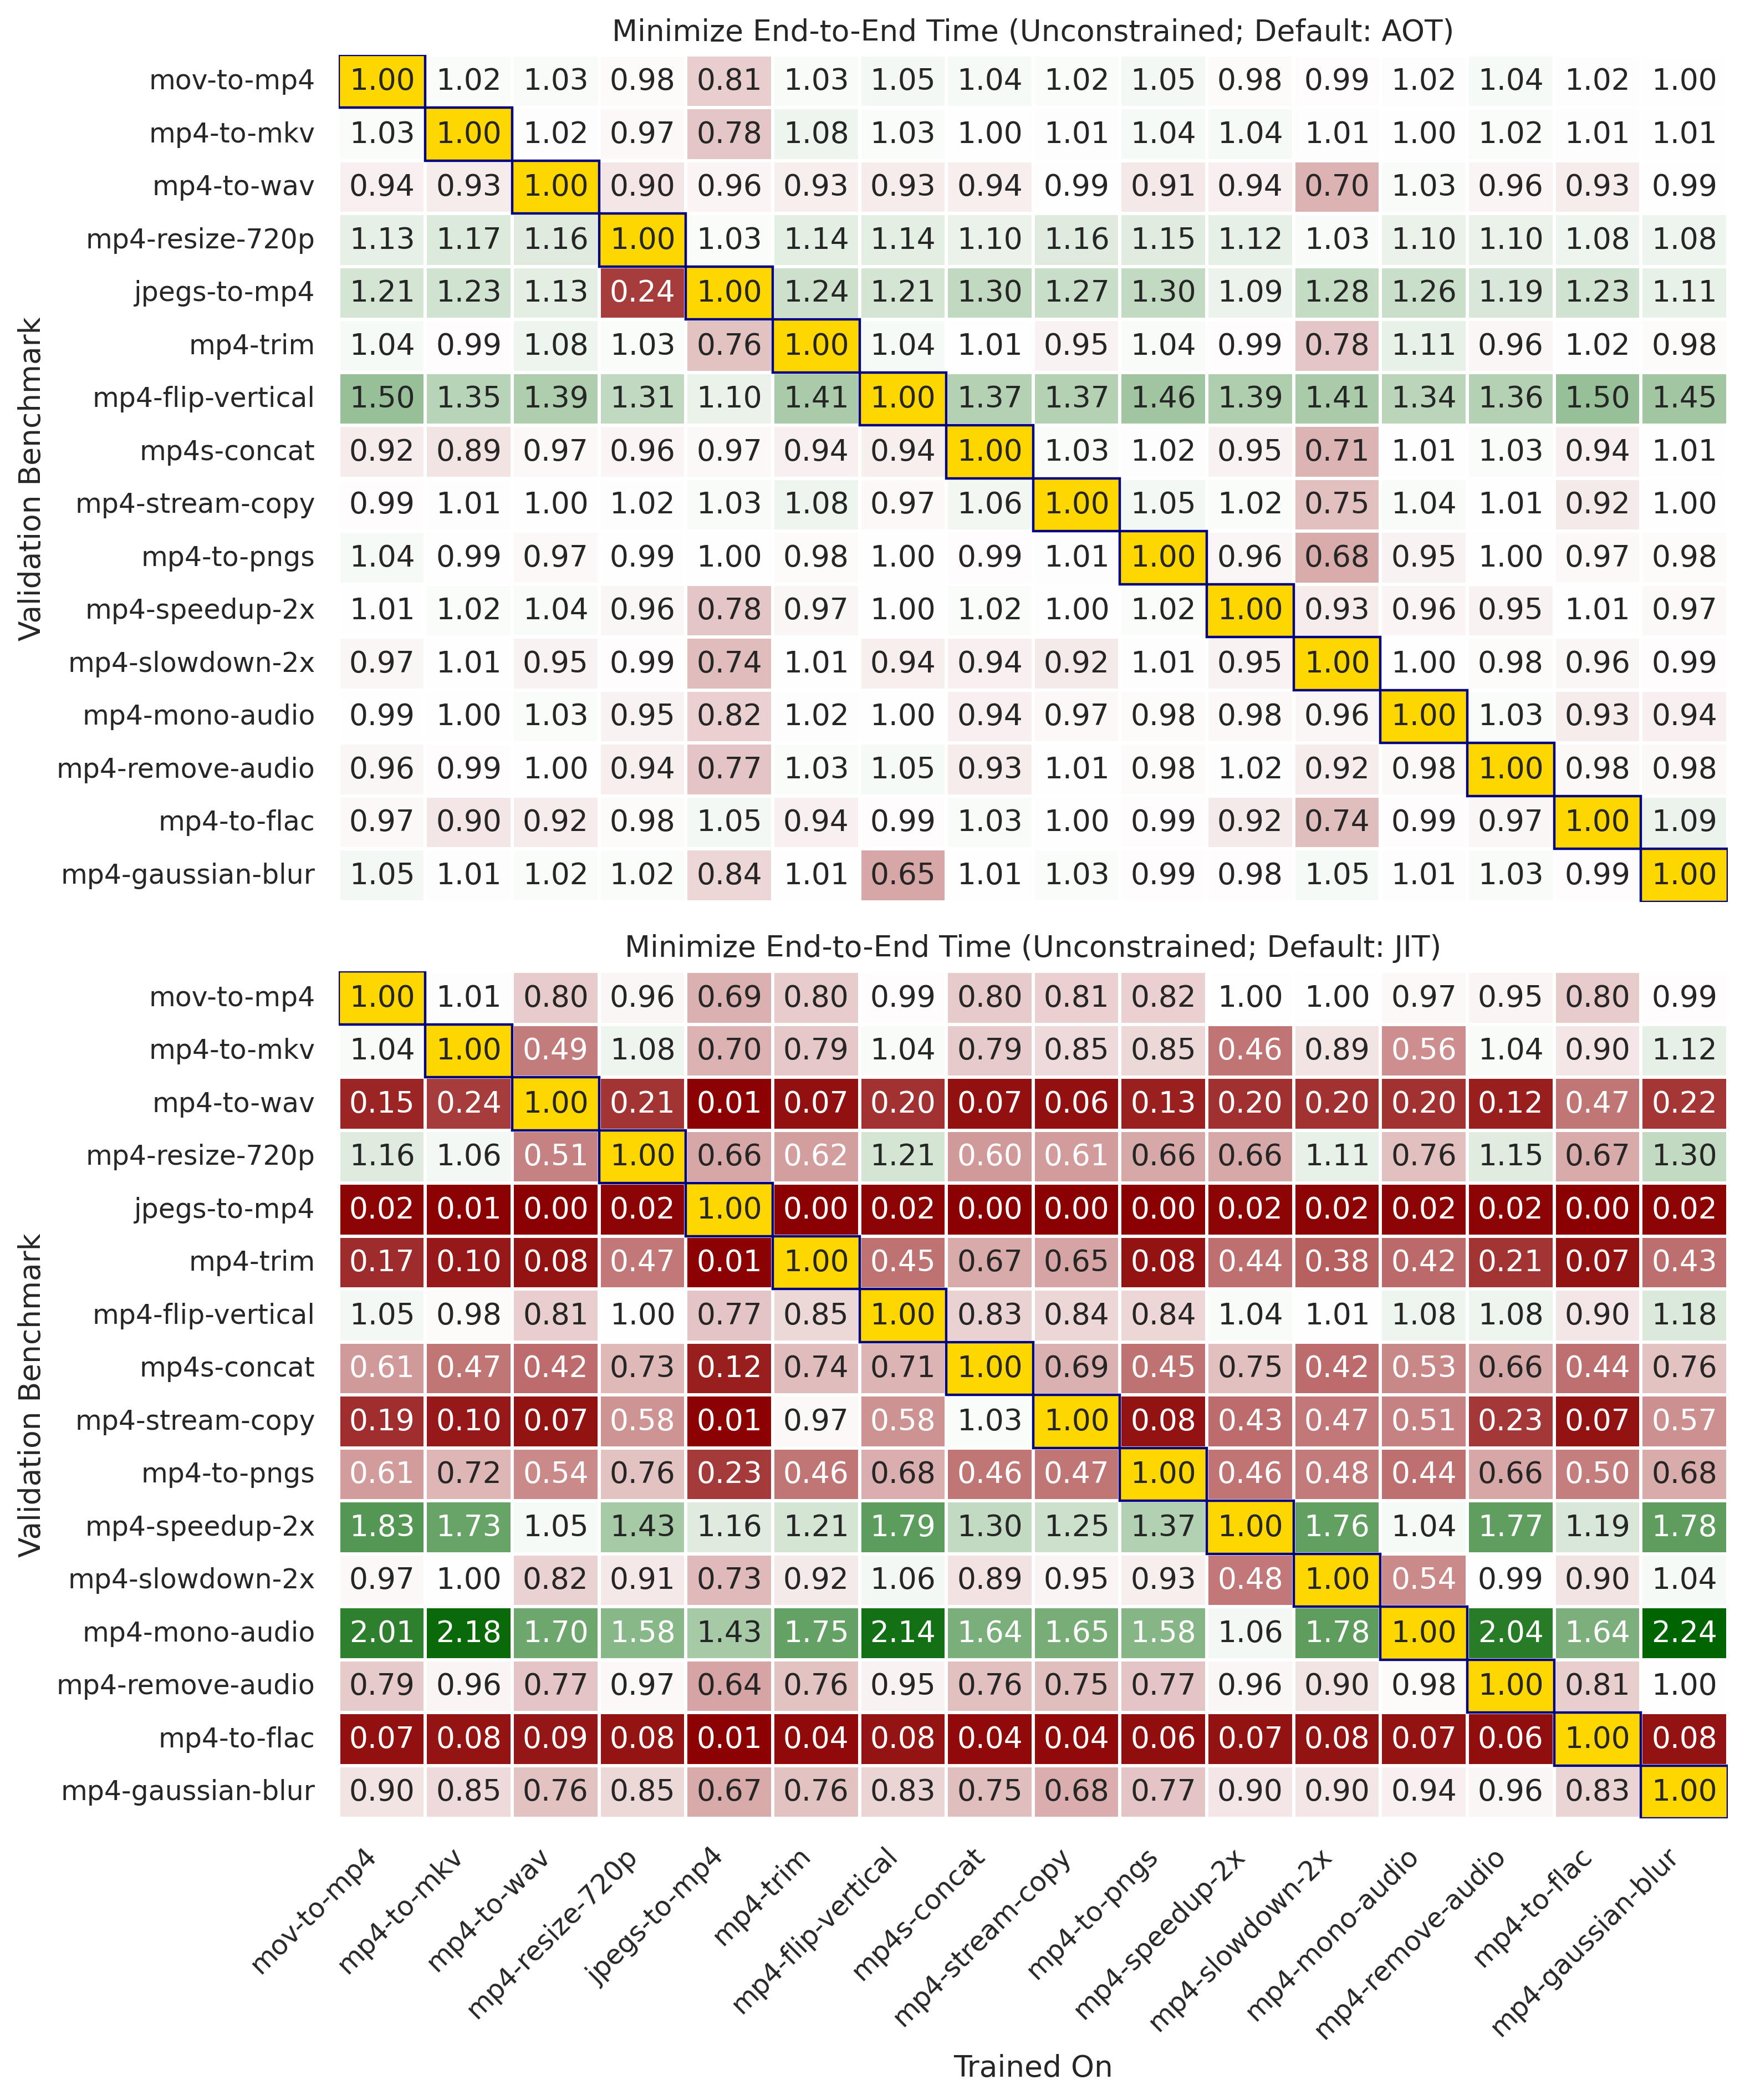

In [21]:
sns.set_theme()
fig, axes = plt.subplots(2, 1, figsize=(10, 12), dpi=320, sharex=True)

# find min and max in both matrice
min_val, max_val = np.min(matrices[0]), np.max(matrices[0])
for matrix in matrices:
    min_val = min(min_val, np.min(matrix))
    max_val = max(max_val, np.max(matrix))

for matrix_idx, matrix in enumerate(matrices):
    # diverging normalization centered at 1
    norm = mcolors.TwoSlopeNorm(
        vmin=min_val,
        vcenter=1,
        vmax=max_val
    )

    # red -> white -> green colormap
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "red_white_green",
        ["darkred", "white", "darkgreen"]
    )

    sns.heatmap(
        matrix,
        cmap=cmap,
        annot=True,
        fmt=".2f",
        ax=axes[matrix_idx],
        linewidths=1,
        linecolor='white',
        norm=norm,
        cbar=False
    )

    # distinguish visaully the diagonal
    for i in range(len(benchmark.workloads)):
        for j in range(len(benchmark.workloads)):
            if i == j:
                axes[matrix_idx].add_patch(plt.Rectangle((i, j), 1, 1, edgecolor='navy', facecolor='gold', linewidth=1))

    axes[matrix_idx].set_xticklabels([wl.name for wl in benchmark.workloads], rotation=45, ha='right')
    axes[matrix_idx].set_yticklabels([wl.name for wl in benchmark.workloads], rotation=0, va='center')

    axes[matrix_idx].set_ylabel('Validation Benchmark')

    axes[matrix_idx].set_title(f'{get_name(plans[matrix_idx])}')

axes[-1].set_xlabel('Trained On')

plt.tight_layout()

# to pdf
# plt.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/matrix_{plan}.pdf', dpi=320)

plt.show()

In [2]:
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *

benchmark = ffmpeg
base_workload = 'mp4-flip-vertical'
for wl in benchmark.workloads:
    print(f'trained_on_{wl.name}')
    plan_path = plans_root(benchmark.binary, base_workload,
                           'min_e2e.unconstrained.default_jit') / f'trained_on_{wl.name}.json'
    print(f'plan_path: {plan_path}')
    plan = plan_json_to_df(plan_path)
    print(plan['mode'].value_counts())
    print()


trained_on_mov-to-mp4
plan_path: /tmp/truejit/plans/ffmpeg/mp4-flip-vertical/min_e2e.unconstrained.default_jit/trained_on_mov-to-mp4.json
mode
jit          25030
static        2442
interpret       18
Name: count, dtype: int64

trained_on_mp4-to-mkv
plan_path: /tmp/truejit/plans/ffmpeg/mp4-flip-vertical/min_e2e.unconstrained.default_jit/trained_on_mp4-to-mkv.json
mode
jit          25016
static        2455
interpret       19
Name: count, dtype: int64

trained_on_mp4-to-wav
plan_path: /tmp/truejit/plans/ffmpeg/mp4-flip-vertical/min_e2e.unconstrained.default_jit/trained_on_mp4-to-wav.json
mode
jit          25798
static        1682
interpret       10
Name: count, dtype: int64

trained_on_mp4-resize-720p
plan_path: /tmp/truejit/plans/ffmpeg/mp4-flip-vertical/min_e2e.unconstrained.default_jit/trained_on_mp4-resize-720p.json
mode
jit          24943
static        2512
interpret       35
Name: count, dtype: int64

trained_on_jpegs-to-mp4
plan_path: /tmp/truejit/plans/ffmpeg/mp4-flip-vertical/min

/tmp/truejit/plans/ffmpeg/mov-to-mp4/min_e2e/trained_on_mov-to-mp4.json


In [2]:
import pandas as pd
import numpy as np
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from solver import *
from profiling import *

In [5]:
benchmark = gcc_loops

In [45]:
static_info = get_static_info(benchmark.binary)
base_profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0]) / 'base.csv')
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e') / 'oracle.json')
df = pd.merge(base_profile, plan, on='id', how='outer')
df

,id,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,start.spec,exec.spec,freq.spec,compilation.spec,size.dynamic.spec,name,size.bytecode,size.static,mode
0,13,7.445630e+06,0.0,1.0,3370841.0,808.0,1.031510e+05,0.000000e+00,1.0,5.553260e+06,0.0,1.0,2504740.0,808.0,__wasm_call_ctors,6.0,808.0,static
1,14,1.198940e+05,0.0,0.0,7323302.0,992.0,9.686400e+04,0.000000e+00,0.0,8.171000e+04,0.0,0.0,5470236.0,992.0,_start,83.0,992.0,static
2,15,8.361211e+08,250000000.0,2621441.0,3988111.0,576.0,9.933332e+06,9.781000e+10,2621441.0,7.183421e+08,260000000.0,2621441.0,4064027.0,576.0,example1(),97.0,576.0,static
3,16,1.104553e+09,230000000.0,1048577.0,7220095.0,696.0,9.841791e+10,5.064000e+10,1048577.0,1.004635e+09,50000000.0,1048577.0,4312257.0,760.0,"example2a(int, int)",204.0,696.0,specialize
4,17,1.379264e+09,410000000.0,524289.0,5905172.0,680.0,1.494409e+11,8.461000e+10,524289.0,1.100103e+09,170000000.0,524289.0,4168370.0,576.0,"example2b(int, int)",192.0,680.0,specialize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
682,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
683,696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
684,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static


In [5]:
class PlanEvaluation:
    def __init__(self, static_info, base_profile, plan):
        e2e = 0
        exec = 0
        waiting = 0
        compilation = 0
        dynamic_code_size = 0
        static_code_size = 0

        # merge on both ('id', 'name')
        df = pd.merge(static_info, base_profile, on=['id', 'name', 'size.bytecode', 'size.static'], how='outer')

        df = pd.merge(df, plan, on='id', how='outer')
        df.drop('name', axis=1, inplace=True)
        df.fillna(0, inplace=True)
        # print(df.to_string())

        # iterate the rows of df
        for i, row in df.iterrows():
            mode = row['mode']
            if mode == 'interpret':
                e2e += row['exec.interp']
                exec += row['exec.interp']
                waiting += 0
                compilation += 0
                dynamic_code_size += 0
                static_code_size += 0
            elif mode == 'jit':
                e2e += row['exec.jit'] + row['compilation.jit']
                exec += row['exec.jit']
                waiting += row['compilation.jit']
                compilation += row['compilation.jit']
                dynamic_code_size += row['size.dynamic.jit']
                static_code_size += 0
            elif mode == 'static':
                e2e += row['exec.jit']  # like jit without compilation/waiting
                exec += row['exec.jit']  # like jit
                waiting += 0
                compilation += 0
                dynamic_code_size += row['size.dynamic.jit']  # also add the dynamic code
                static_code_size += row['size.static']
            elif mode == 'async':
                e2e += row['exec.jit'] + .5 * row[
                    'compilation.jit']  # assume async compilation happens in parallel with execution, so we only add half of the compilation time to e2e
                exec += row['exec.jit']
                waiting += .5 * row[
                    'compilation.jit']  # assume async compilation happens in parallel with execution, so we only add half of the compilation time to waiting
                compilation += row['compilation.jit']
                dynamic_code_size += row['size.dynamic.jit']
                static_code_size += 0
            elif mode == 'specialize':
                e2e += row['exec.spec'] + row['compilation.spec']
                exec += row['exec.spec']
                waiting += row['compilation.spec']
                compilation += row['compilation.spec']
                dynamic_code_size += row['size.dynamic.spec']
                static_code_size += 0
            else:
                raise ValueError(f'Unknown mode: {mode}')

        plan_modes = plan['mode'].value_counts().to_dict()
        self.jit = plan_modes.get('jit', 0)
        self.interpret = plan_modes.get('interpret', 0)
        self.async_compilation = plan_modes.get('async', 0)
        self.specialize = plan_modes.get('specialize', 0)
        self.static = plan_modes.get('static', 0)

        self.e2e = e2e
        self.exec = exec
        self.waiting = waiting
        self.compilation = compilation
        self.dynamic_code_size = dynamic_code_size
        self.static_code_size = static_code_size

    def __str__(self):
        return json.dumps({
            'jit': self.jit,
            'interpret': self.interpret,
            'async_compilation': self.async_compilation,
            'specialize': self.specialize,
            'static': self.static,
            'e2e': self.e2e,
            'exec': self.exec,
            'waiting': self.waiting,
            'compilation': self.compilation,
            'dynamic_code_size': self.dynamic_code_size,
            'static_code_size': self.static_code_size,
        }, indent=2)


PlanEvaluation(static_info, base_profile, plan)

In [6]:
class Planning:
    def __init__(self, goal, constraints, default):
        self.goal = goal
        self.constraints = constraints
        self.default = default

    def get_plan(self, static_info, base_profile):
        all_ids = static_info['id'].tolist()
        if self.goal is None:
            return pd.DataFrame({'id': all_ids, 'mode': [self.default] * len(all_ids)})
        solver = Solver(base_profile)
        solver.solve(self.goal, self.constraints, timeout=10)
        plan = solver.plan
        unplanned_ids = set(all_ids) - set(plan['id'].tolist())
        defaults = pd.DataFrame({'id': list(unplanned_ids), 'mode': [self.default] * len(unplanned_ids)})
        return pd.concat([plan, defaults])

In [7]:
plans = []
plans.append(('Interpreter', Planning(None, None, 'interpret')))
plans.append(('JIT', Planning(None, None, 'jit')))
plans.append(('AOT', Planning(None, None, 'static')))
plans.append(('Code = 0',
              Planning(EndToEndTime(),
                       [Constraint(StaticCodeSize(), upper_bound=0), Constraint(DynamicCodeSize(), upper_bound=0)],
                       'interpret')))
plans.append((r'Code $< 10\,\mathrm{KB}$',
              Planning(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=10_000),
                                        Constraint(DynamicCodeSize(), upper_bound=10_000)], 'interpret')))

plans.append((r'Code $< 200\,\mathrm{KB}$',
              Planning(EndToEndTime(), [Constraint(StaticCodeSize(), upper_bound=100_000),
                                        Constraint(DynamicCodeSize(), upper_bound=100_000)], 'interpret')))

# plans.append(('Code < 1MB (Default: interpret)',
#               Planning(EndToEndTime(), [Constraint(DynamicCodeSize(), upper_bound=1_000_000)], 'interpret')))
plans.append(('Unbounded Code',
              Planning(EndToEndTime(), [], 'static')))

evaluations = []
for plan_title, planning in plans:
    print(plan_title)
    plan = planning.get_plan(static_info, base_profile)
    evaluation = PlanEvaluation(static_info, base_profile, plan)
    print(evaluation)
    evaluations.append(evaluation)
    print("---------")

Interpreter
{
  "jit": 0,
  "interpret": 686,
  "async_compilation": 0,
  "specialize": 0,
  "static": 0,
  "e2e": 1280620000000.0,
  "exec": 1280620000000.0,
  "waiting": 0,
  "compilation": 0,
  "dynamic_code_size": 0,
  "static_code_size": 0
}
---------
JIT
{
  "jit": 686,
  "interpret": 0,
  "async_compilation": 0,
  "specialize": 0,
  "static": 0,
  "e2e": 6800415875.0,
  "exec": 5220000000.0,
  "waiting": 1580415875.0,
  "compilation": 1580415875.0,
  "dynamic_code_size": 208664.0,
  "static_code_size": 0
}
---------
AOT
{
  "jit": 0,
  "interpret": 0,
  "async_compilation": 0,
  "specialize": 0,
  "static": 686,
  "e2e": 5220000000.0,
  "exec": 5220000000.0,
  "waiting": 0,
  "compilation": 0,
  "dynamic_code_size": 208664.0,
  "static_code_size": 905640
}
---------
Code = 0
[goal] EndToEndTime
[constraint] StaticCodeSize <= 0
[constraint] DynamicCodeSize <= 0
Solving...
[status] Optimal
[elapsed time] 0.01 seconds
{
  "jit": 0,
  "interpret": 686,
  "async_compilation": 0,
  "s

In [8]:
from bokeh.palettes import *

colors = [
    'cyan',
    'green',
    'purple',
]
for i in range(len(plans[3:])):
    colors.append('blue')

In [9]:
code_sizes = [e.static_code_size + e.dynamic_code_size for e in evaluations]
e2es = [e.e2e for e in evaluations]
plans_titles = [plan_title for plan_title, _ in plans]

In [1]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif"],
})

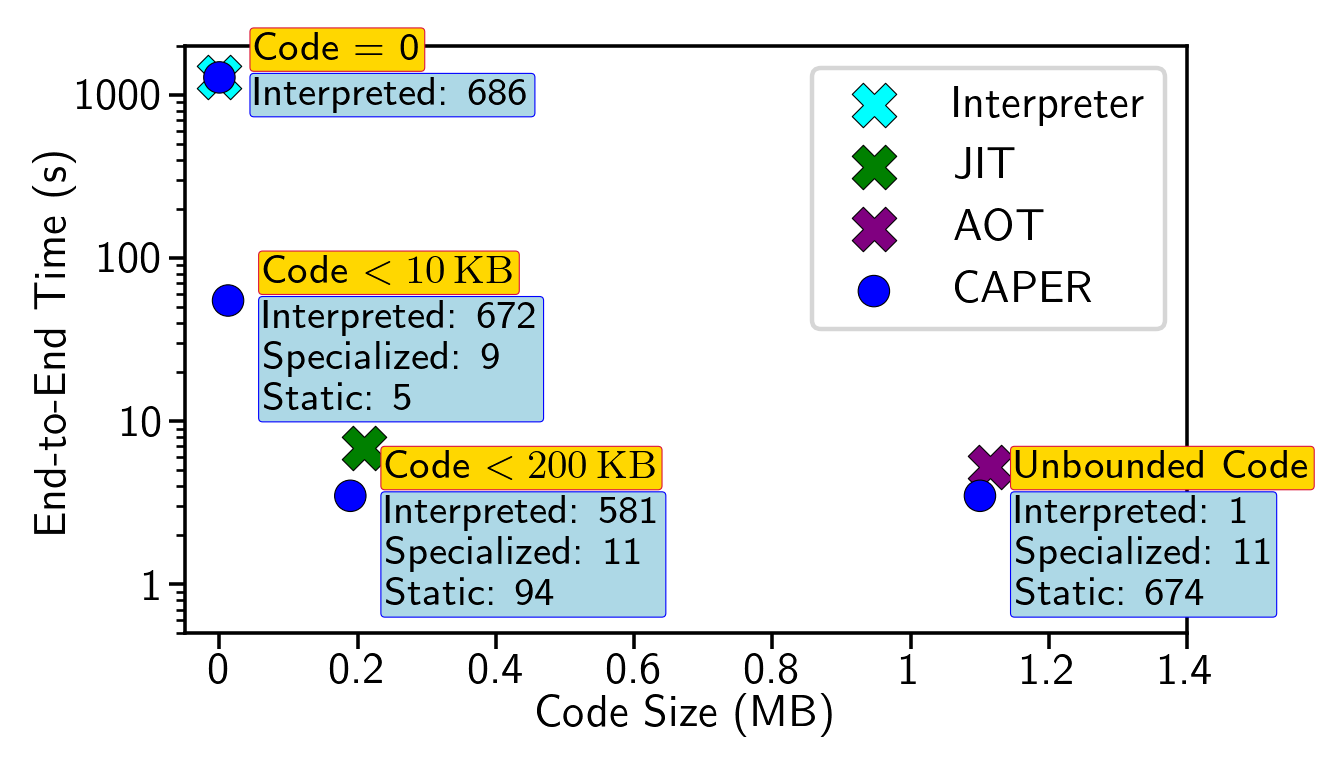

In [47]:


fig, ax = plt.subplots(figsize=(4, 2.2), dpi=320)

linewidth = 0.25
ax.scatter(code_sizes[0], e2es[0], color=colors[0], label=plans_titles[0], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[1], e2es[1], color=colors[1], label=plans_titles[1], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)
ax.scatter(code_sizes[2], e2es[2], color=colors[2], label=plans_titles[2], alpha=1, edgecolor='black',
           linewidth=linewidth, marker='X', s=100)

ax.scatter(code_sizes[3:], e2es[3:], color=colors[3:], label='CAPER', alpha=1, edgecolor='black', linewidth=linewidth,
           marker='o', s=50)

LEFT_PADDING = 50000
for i in range(len(plans[3:])):
    eval = evaluations[3 + i]
    text = plans_titles[3 + i]
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1.9, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='gold', edgecolor='crimson', linewidth=linewidth, boxstyle='round,pad=0.1'))
    text = ''
    if eval.interpret:
        text += f'Interpreted: {eval.interpret}\n'
    if eval.jit:
        text += f'JIT: {eval.jit}\n'
    if eval.specialize:
        text += f'Specialized: {eval.specialize}\n'
    if eval.async_compilation:
        text += f'Async: {eval.async_compilation}\n'
    if eval.static:
        text += f'Static: {eval.static}\n'
    text = text.strip()
    ax.text(code_sizes[3 + i] + LEFT_PADDING, e2es[3 + i] * 1, text, fontsize=9, ha='left', va='top', color='black',
            bbox=dict(facecolor='lightblue', edgecolor='blue', linewidth=linewidth, boxstyle='round,pad=0.1'))

# make y log
ax.set_ylim(5e8, 2e12)
ax.set_yscale('log')
ax.set_yticks([1e9, 1e10, 1e11, 1e12])
ax.set_yticklabels(['1', '10', '100', '1000'])

# set x lim to 1.5MB
ax.set_xlim(-50000, 1400000)
# 0, 200k, 400k, 600k, ..., 1MB
ax.set_xticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000, 1400000])
ax.set_xticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1', '1.2', '1.4'])

ax.tick_params(axis='both', pad=1)

ax.set_xlabel('Code Size (MB)', labelpad=0)
ax.set_ylabel('End-to-End Time (s)', labelpad=0)
# ax.set_title(f'{benchmark.name} Compilation Plans Comparison')
ax.legend()

# make it tight
plt.tight_layout(pad=0)

# to pdf
plt.savefig(f'/tmp/truejit/evaluation/compilation-plan/out/motivation.pdf', bbox_inches='tight', dpi=320, format='pdf')

plt.show()

In [63]:
benchmark = gcc_loops
static_info = get_static_info(benchmark.binary)
base_profile = pd.read_csv(profiles_root(benchmark.binary, benchmark.workloads[0].name) / 'base.csv')
plan = plan_json_to_df(plans_root(benchmark.binary, benchmark.workloads[0].name, 'min_e2e') / 'oracle.json')
df = pd.merge(base_profile, plan, on='id', how='outer')
df

,id,start.jit,exec.jit,freq.jit,compilation.jit,size.dynamic.jit,start.interp,exec.interp,freq.interp,start.spec,exec.spec,freq.spec,compilation.spec,size.dynamic.spec,name,size.bytecode,size.static,mode
0,13,7.445630e+06,0.0,1.0,3370841.0,808.0,1.031510e+05,0.000000e+00,1.0,5.553260e+06,0.0,1.0,2504740.0,808.0,__wasm_call_ctors,6.0,808.0,static
1,14,1.198940e+05,0.0,0.0,7323302.0,992.0,9.686400e+04,0.000000e+00,0.0,8.171000e+04,0.0,0.0,5470236.0,992.0,_start,83.0,992.0,static
2,15,8.361211e+08,250000000.0,2621441.0,3988111.0,576.0,9.933332e+06,9.781000e+10,2621441.0,7.183421e+08,260000000.0,2621441.0,4064027.0,576.0,example1(),97.0,576.0,static
3,16,1.104553e+09,230000000.0,1048577.0,7220095.0,696.0,9.841791e+10,5.064000e+10,1048577.0,1.004635e+09,50000000.0,1048577.0,4312257.0,760.0,"example2a(int, int)",204.0,696.0,specialize
4,17,1.379264e+09,410000000.0,524289.0,5905172.0,680.0,1.494409e+11,8.461000e+10,524289.0,1.100103e+09,170000000.0,524289.0,4168370.0,576.0,"example2b(int, int)",192.0,680.0,specialize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
681,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
682,695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
683,696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static
684,697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,static


In [64]:
df = base_profile[['id', 'start.jit']]
df = pd.merge(df, plan, on='id', how='left')
# sort by 'start.jit'
df = df.sort_values('start.jit')
df

,id,start.jit,mode
0,14,119894,static
1,13,7445630,static
2,142,10818247,static
3,117,15039524,static
4,116,20271086,static
...,...,...,...
140,409,6789549566,static
141,609,6798794929,static
142,113,6804824328,static
143,624,6810086664,static


In [65]:
for i, row in df.iterrows():
    print(f'[{i} id={row['id']} mode={row["mode"]}]')

[0 id=14 mode=static]
[1 id=13 mode=static]
[2 id=142 mode=static]
[3 id=117 mode=static]
[4 id=116 mode=static]
[5 id=61 mode=static]
[6 id=367 mode=static]
[7 id=363 mode=static]
[8 id=331 mode=static]
[9 id=681 mode=static]
[10 id=332 mode=static]
[11 id=144 mode=static]
[12 id=156 mode=static]
[13 id=362 mode=static]
[14 id=333 mode=static]
[15 id=386 mode=static]
[16 id=334 mode=static]
[17 id=335 mode=static]
[18 id=336 mode=static]
[19 id=405 mode=static]
[20 id=599 mode=static]
[21 id=597 mode=static]
[22 id=678 mode=static]
[23 id=337 mode=static]
[24 id=338 mode=static]
[25 id=339 mode=static]
[26 id=340 mode=static]
[27 id=341 mode=static]
[28 id=451 mode=static]
[29 id=342 mode=static]
[30 id=452 mode=static]
[31 id=343 mode=static]
[32 id=344 mode=static]
[33 id=345 mode=static]
[34 id=346 mode=static]
[35 id=347 mode=static]
[36 id=348 mode=static]
[37 id=349 mode=static]
[38 id=350 mode=static]
[39 id=351 mode=static]
[40 id=352 mode=static]
[41 id=353 mode=static]
[42 i

num=145 columns=100 rows=2


(0.0, 1.0)

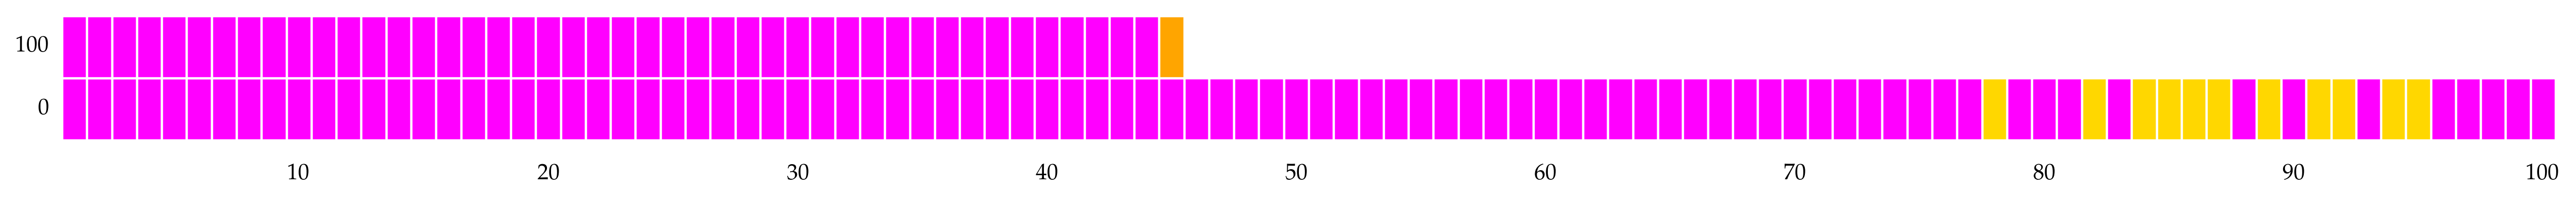

In [83]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

num = len(df)
columns = 100
rows = num // columns + (1 if num % columns != 0 else 0)
print(f'num={num} columns={columns} rows={rows}')

get_cell = lambda i: (i % columns, i // columns)
get_color = lambda mode: {
    'interpret': 'orange',
    'jit': 'crimson',
    'static': 'magenta',
    'specialize': 'gold',
    'async': 'cyan',
}[mode]

cell_width = .2
cell_height = .5

fig, ax = plt.subplots(figsize=(cell_width * columns, cell_height * rows), dpi=320)
ax.set_aspect('equal')

for i, row in df.iterrows():
    x, y = get_cell(i)
    x *= cell_width
    y *= cell_height
    color = get_color(row['mode'])
    ax.add_patch(plt.Rectangle((x, y), cell_width, cell_height, facecolor=color, edgecolor='white', linewidth=1))
    # ax.text(x + cell_width / 2, y + cell_height / 2, str(row['id']), ha='center', va='center')

# x-axis labels
for i in range(columns):
    val = i + 1
    if val % 10 == 0:
        ax.text((i + .5) * cell_width, (0 - .5) * cell_height, str(val), ha='center', va='center_baseline')

# y-axis labels
for i in range(rows):
    val = i * columns
    ax.text((0 - .5) * cell_width, (i + .5) * cell_height, str(val), ha='right', va='center')

ax.axis('off')

ax.set_xlim(0, columns * cell_width)
ax.set_ylim(0, rows * cell_height)

In [13]:
benchmark = ffmpeg

plan_mode = 'min_e2e'
wl = 'mp4-to-pngs'
before, after = 'oracle', 'trained_on_mov-to-mp4'

In [14]:
df = pd.merge(df, plans, on='id', how='left')
print(df['exec.diff'].sum())
df = df[[]]

NameError: name 'df' is not defined

In [18]:
def plan_diff(binary, wl, plan_mode, before, after):
    before_plan = plan_json_to_df(plans_root(binary, wl, plan_mode) / f'{before}.json')
    # print(before_plan['mode'].value_counts())
    after_plan = plan_json_to_df(plans_root(binary, wl, plan_mode) / f'{after}.json')
    print(after_plan['mode'].value_counts())
    plans = pd.merge(before_plan, after_plan, on='id', how='outer', suffixes=['.before', '.after'])

    before_profile = get_profile(profiles_root(binary, wl, plan_mode) / before)
    after_profile = get_profile(profiles_root(binary, wl, plan_mode) / after)

    e2e_diff = Profile(profiles_root(binary, wl, plan_mode) / after).e2e - Profile(
        profiles_root(binary, wl, plan_mode) / before).e2e
    print(f'{e2e_diff} e2e_diff')
    e2e_diff = Profile(profiles_root(binary, wl, plan_mode) / after).e2e / Profile(
        profiles_root(binary, wl, plan_mode) / before).e2e
    print(f'{e2e_diff} e2e_diff_ratio')

    merged_profile = pd.merge(before_profile, after_profile, on='id', how='outer', suffixes=['.before', '.after'])
    metrics = ['freq', 'exec', 'compilation', 'size.dynamic']

    df = pd.DataFrame({'id': merged_profile['id']})
    for metric in metrics:
        df[f'{metric}.diff'] = merged_profile[f'{metric}.after'] - merged_profile[f'{metric}.before']
        if (df[f'{metric}.diff'] == 0).all():
            df = df.drop(f'{metric}.diff', axis=1)

    df = pd.merge(plans, df, on='id', how='right')
    return df


before = 'trained_on_mp4-to-pngs'
before = 'trained_on_mp4-gaussian-blur'
before = 'trained_on_mp4-to-wav'
dfs = []
for w in benchmark.workloads:
    after = f'trained_on_{w.name}'
    print(after)
    plan_mode = 'min_e2e'
    plan_mode = 'min_e2e.default_jit'
    # plan_mode = 'min_e2e.file_size_lt_5percent'
    df = plan_diff(benchmark.binary, w.name, plan_mode, before, after)
    # sort df by exec diff
    if 'exec.diff' in df:
        df = df.sort_values('exec.diff')
    # print(df.head().to_string(index=False))

    dfs.append(df)

    # print(sum(df['exec.diff']))
    print()
    print()
    print()

# mode
# jit          25798
# static        1688
# interpret        4
# Name: count, dtype: int64

trained_on_mov-to-mp4
mode
jit          25030
static        2454
interpret        6
Name: count, dtype: int64
-26562839401 e2e_diff
0.7978989414343193 e2e_diff_ratio



trained_on_mp4-to-mkv
mode
jit          25016
static        2472
interpret        2
Name: count, dtype: int64
-24806346521 e2e_diff
0.805039528844252 e2e_diff_ratio



trained_on_mp4-to-wav
mode
jit          25798
static        1688
interpret        4
Name: count, dtype: int64
0 e2e_diff
1.0 e2e_diff_ratio



trained_on_mp4-resize-720p
mode
jit          24943
static        2540
interpret        7
Name: count, dtype: int64
-27693133065 e2e_diff
0.5018031311951487 e2e_diff_ratio



trained_on_jpegs-to-mp4
mode
jit          26109
static        1379
interpret        2
Name: count, dtype: int64
-20989388149 e2e_diff
0.0011799349699968707 e2e_diff_ratio



trained_on_mp4-trim
mode
jit          25954
static        1533
interpret        3
Name: count, dtype: int64
-1903760700 e2e_diff
0.07566472608298543 e2e_diff_ratio



train

In [19]:
dfs[0]

,id,mode.before,mode.after,freq.diff,exec.diff,compilation.diff,size.dynamic.diff
282,534,jit,static,0,-350000000,-30511333,-2224
339,647,jit,static,0,-190000000,-2543060,-568
323,623,jit,static,0,-180000000,-11197323,-1592
264,500,jit,static,0,-170000000,-6833999,-1208
324,624,jit,static,0,-160000000,-19141180,-1400
...,...,...,...,...,...,...,...
539,1786,static,static,-199,120000000,0,0
2115,16932,jit,static,0,120000000,-3718960,-600
277,525,jit,static,0,130000000,-12563410,-1080
338,646,jit,static,0,140000000,-24813335,-1520


In [47]:
import pandas as pd
import numpy as np
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *
from utils import *

benchmark = ffmpeg
workload_name = 'mov-to-mp4'
history = get_history(benchmark.binary, workload_name)
history = pd.DataFrame(history, columns=['id'])


def dry_run(plan, profile, history):
    df = pd.merge(profile, plan, on='id', how='left')
    df = pd.merge(history, df, on='id', how='left')

    e2e = 0
    for i, row in df.iterrows():
        mode = row['mode']
        if mode == 'static':
            e2e += row['exec.jit']
        elif mode == 'interpret':
            e2e += row['exec.interp']
        else:
            raise RuntimeError('Unknown mode {}'.format(mode))
    return e2e


plan_mode = 'min_e2e.unconstrained.default_jit'
plan = plan_json_to_df(plans_root(benchmark.binary, workload_name, plan_mode) / f'oracle.json')
profile = pd.read_csv(profiles_root(benchmark.binary, workload_name) / f'oracle.csv')

actual_profile = Profile(profiles_root(benchmark.binary, workload_name, plan_mode) / 'oracle')
print(actual_profile.e2e)
plan_e2e = dry_run(plan, profile, history)
print(plan_e2e)

[91331940543, 96086497106, 84390047415, 80494415673, 89042704667, 91210895449, 92234899099, 90003529061, 75478416589, 74799486578, 84726222029, 86050657458, 109880085233, 84186271030, 122695492263, 74714656772, 75843454053, 115819089297, 96907748817, 85970904342]
74292000000


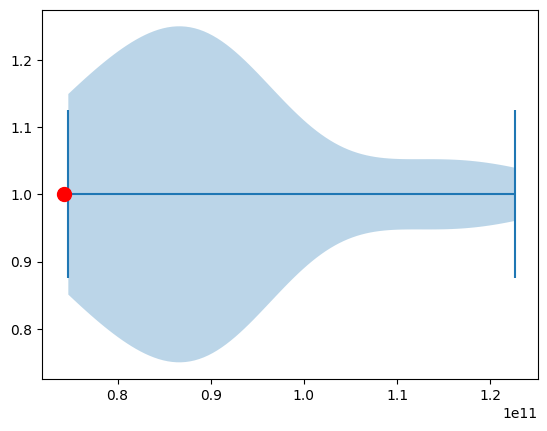

In [46]:
import matplotlib.pyplot as plt

single_point = 74292000000

points = [
    91331940543, 96086497106, 84390047415, 80494415673, 89042704667,
    91210895449, 92234899099, 90003529061, 75478416589, 74799486578,
    84726222029, 86050657458, 109880085233, 84186271030, 122695492263,
    74714656772, 75843454053, 115819089297, 96907748817, 85970904342
]

# x positions
x_points = np.zeros(len(points))

# plot the list
plt.violinplot(points, vert=False)

# plot the single point
plt.plot(single_point, [1], marker='o', markersize=10, color='red')

# plt.legend()
plt.show()

In [7]:
profiles_root(benchmark.binary, workload_name, 'jit')

PosixPath('/tmp/truejit/profiles/ffmpeg/mp4-vertical-flip/jit')

In [9]:
benchmark = ffmpeg
workload_name = 'mp4-flip-vertical'
profile = Profile(profiles_root(benchmark.binary, workload_name, 'jit'))


[125343961450,
 125086876503,
 125506734842,
 125205552309,
 125788110537,
 125659908801,
 125852533183,
 125476816571,
 125551620338,
 126385338526,
 125416012414,
 125663572145,
 125524456108,
 125165275622,
 125279994456,
 125612212760,
 130967212911,
 125183293264,
 125123561059,
 125298865385,
 125107523597,
 125023893541,
 125801366812,
 125613851363,
 125457927283]

In [ ]:
# violin plot profile.e2e
import 

In [5]:
import sys

sys.path.append('/tmp/truejit/evaluation/compilation-plan')
from profiling import *
from utils import *

benchmark = ffmpeg

selected = 'mov-to-mp4'
selected = 'mp4-to-wav'
selected = 'mp4-gaussian-blur'
plan_mode = 'min_e2e.unconstrained.default_jit'
# plan_mode = 'min_e2e.file_size_lt_5percent'
plans = []
baseline_profile = Profile(profiles_root(benchmark.binary, selected, plan_mode) / f'trained_on_{selected}')

for wl in benchmark.workloads:
    plan = json.load(open(plans_root(benchmark.binary, selected, plan_mode) / f'trained_on_{wl.name}.json'))
    profile = Profile(profiles_root(benchmark.binary, selected, plan_mode) / f'trained_on_{wl.name}')
    plans.append((wl.name, len(plan['static']), len(plan['interpret']), len(plan['specialize']), len(plan['async']),
                  len(plan['jit'])
                  # , profile.e2e, profile.exec, profile.waiting, profile.compilation
                  ))

df = pd.DataFrame(plans,
                  columns=[
                      'workload', 'static', 'interpret', 'specialize', 'async', 'jit',
                      # 'e2e', 'exec', 'waiting','compilation'
                  ])
df

,workload,static,interpret,specialize,async,jit
0,mov-to-mp4,2442,18,0,0,25030
1,mp4-to-mkv,2455,19,0,0,25016
2,mp4-to-wav,1682,10,0,0,25798
3,mp4-resize-720p,2512,35,0,0,24943
4,jpegs-to-mp4,1373,8,0,0,26109
5,mp4-trim,1531,5,0,0,25954
6,mp4-flip-vertical,2441,20,0,0,25029
7,mp4s-concat,1606,10,0,0,25874
8,mp4-stream-copy,1521,9,0,0,25960
9,mp4-to-pngs,1849,14,0,0,25627


In [49]:
# read pandas datafrom from csv profiles_root(benchmark.binary, selected) / 'base.csv'
df = pd.read_csv(profiles_root(benchmark.binary, selected) / 'base.csv')
df['jit.e2e'] = df['exec.jit'] + df['compilation.jit']
df['interp.e2e'] = df['exec.interp']
df['diff'] = df['jit.e2e'] / df['interp.e2e']
df[['jit.e2e', 'interp.e2e', 'diff']]
# plot jit e2e agains interp


,jit.e2e,interp.e2e,diff
0,4767171,0,inf
1,2419665,0,inf
2,2306526,0,inf
3,2277623,10000000,0.227762
4,6437299,0,inf
...,...,...,...
2483,1720028,0,inf
2484,2185760,0,inf
2485,1708724,0,inf
2486,9937269,0,inf


<Axes: xlabel='exec.jit', ylabel='exec.interp'>

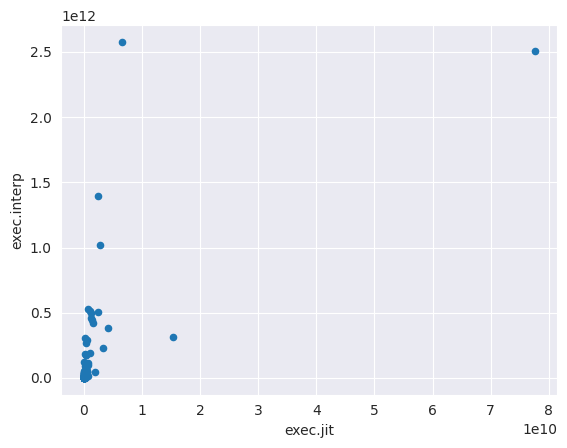

In [57]:
df[['jit.e2e', 'interp.e2e', 'diff']]
# plot jit e2e agains interp scatter
import seaborn as sns

sns.set_style('darkgrid')

df[df['exec.interp'] > 0].plot.scatter(x='exec.jit', y='exec.interp')